In [1]:
import os
os.environ["NUMBA_DISABLE_JIT"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from data.data_processor_fix import DataProcessor as DP
from data.splitter import SurvivalSplitter
from models.cox_model_upd import CoxModelUpd
from models.rsf_model import RSFModel
from metrics.ibs import IBSMetric
from metrics.auprc import AUPRCMetric
from metrics.evaluator import SurvivalEvaluator
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv('data/individual_custody_timeline_rfm.csv')
df.info()
#print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18668 entries, 0 to 18667
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     18668 non-null  object 
 1   age                      18668 non-null  int64  
 2   sex                      18668 non-null  object 
 3   race                     18668 non-null  object 
 4   c_charge_degree          17883 non-null  object 
 5   c_charge_desc            17870 non-null  object 
 6   in_custody               18074 non-null  object 
 7   out_custody              18074 non-null  object 
 8   custody_num              18668 non-null  int64  
 9   time_to_last_custody     7797 non-null   float64
 10  time_since_last_arrest   7797 non-null   float64
 11  time_to_future_arrest    7797 non-null   float64
 12  event                    18668 non-null  int64  
 13  event_of_future_arrest   18668 non-null  int64  
 14  curr_dur_custody      

In [3]:
processor = DP("data/individual_custody_timeline_rfm.csv")
cox_df = processor.load_and_prepare()
cox_df['c_charge_degree'] = cox_df['c_charge_degree'].str.strip('()')
cox_df['race'] = cox_df['race'].str.strip('').str.upper()
cox_df['sex'] = cox_df['sex'].str.strip().str.upper()
sex_mapping = {
    'MALE': 0,
    'FEMALE': 1
}
cox_df['sex'] = cox_df['sex'].map(sex_mapping)
cox_df.head()
cox_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7772 entries, 0 to 7771
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   name                    7772 non-null   object 
 1   episode_col             7772 non-null   int64  
 2   start                   7772 non-null   float64
 3   stop                    7772 non-null   float64
 4   event                   7772 non-null   int64  
 5   age                     7772 non-null   int64  
 6   sex                     7772 non-null   int64  
 7   race                    7772 non-null   object 
 8   c_charge_degree         7667 non-null   object 
 9   time_since_last_arrest  7772 non-null   float64
 10  average_dur_custody     7772 non-null   float64
 11  curr_dur_custody        7772 non-null   float64
dtypes: float64(5), int64(4), object(3)
memory usage: 728.8+ KB


In [4]:
custody_stats = cox_df.groupby("name")["curr_dur_custody"].agg(["min", "max"]).reset_index()
custody_stats.columns = ["name", "min_custody", "max_custody"]

# last_charge = cox_df.sort_values("episode_col").groupby("name")["c_charge_degree"].last().reset_index()
# last_charge.columns = ["name", "last_charge_degree"]

cox_df = cox_df.merge(custody_stats, on="name", how="left")
#cox_df = cox_df.merge(last_charge, on="name", how="left")

cox_df.head(10)

,name,episode_col,start,stop,event,age,sex,race,c_charge_degree,time_since_last_arrest,average_dur_custody,curr_dur_custody,min_custody,max_custody
0,aajah herrington,1,0.0,385.0,0,23,1,AFRICAN-AMERICAN,F3,384.0,1.00,23.0,23.0,23.0
1,aaron aprile,1,0.0,55.0,0,27,0,HISPANIC,F3,0.0,55.00,510.0,510.0,510.0
2,aaron davis,1,0.0,432.0,0,41,0,CAUCASIAN,F3,314.0,118.00,8.0,8.0,8.0
3,aaron eddins,1,0.0,104.0,0,37,0,AFRICAN-AMERICAN,M1,104.0,0.00,32.0,32.0,32.0
4,aaron epstein,1,0.0,297.0,1,22,0,CAUCASIAN,F3,296.0,1.00,1.0,1.0,50.0
5,aaron epstein,2,297.0,357.0,1,22,0,CAUCASIAN,F3,59.0,1.00,50.0,1.0,50.0
6,aaron epstein,3,357.0,430.0,0,22,0,CAUCASIAN,F3,23.0,17.33,10.0,1.0,50.0
7,aaron evans,1,0.0,95.0,1,26,0,AFRICAN-AMERICAN,F3,94.0,1.00,0.0,0.0,14.0
8,aaron evans,2,95.0,318.0,1,26,0,AFRICAN-AMERICAN,F3,223.0,0.50,1.0,0.0,14.0
9,aaron evans,3,318.0,425.0,0,26,0,AFRICAN-AMERICAN,F3,106.0,0.67,14.0,0.0,14.0


In [5]:
cox_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7772 entries, 0 to 7771
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   name                    7772 non-null   object 
 1   episode_col             7772 non-null   int64  
 2   start                   7772 non-null   float64
 3   stop                    7772 non-null   float64
 4   event                   7772 non-null   int64  
 5   age                     7772 non-null   int64  
 6   sex                     7772 non-null   int64  
 7   race                    7772 non-null   object 
 8   c_charge_degree         7667 non-null   object 
 9   time_since_last_arrest  7772 non-null   float64
 10  average_dur_custody     7772 non-null   float64
 11  curr_dur_custody        7772 non-null   float64
 12  min_custody             7772 non-null   float64
 13  max_custody             7772 non-null   float64
dtypes: float64(7), int64(4), object(3)
memor

In [6]:
rare_threshold = 40
value_counts = cox_df['c_charge_degree'].value_counts()
rare_categories = value_counts[value_counts < rare_threshold].index.tolist()
cox_df['c_charge_degree'] = cox_df['c_charge_degree'].replace(rare_categories, 'OTHER')
# rare_threshold1 = 10
# value_counts1 = cox_df['last_charge_degree'].value_counts()
# rare_categories1 = value_counts1[value_counts1 < rare_threshold1].index.tolist()
# cox_df['last_charge_degree'] = cox_df['last_charge_degree'].replace(rare_categories1, 'OTHER')

Data split into train and test data

In [7]:
splitter = SurvivalSplitter(test_size=0.2)
train_df, test_df = splitter.split_by_individual(cox_df)
train_df = train_df.drop(columns=["curr_dur_custody"])
test_df = test_df.drop(columns=["curr_dur_custody"])
train_df["time"] = train_df["stop"] - train_df["start"]
test_df["time"] = test_df["stop"] - test_df["start"]

print("Train individuals:", train_df["name"].nunique())
print("Test individuals:", test_df["name"].nunique())

Train individuals: 3382
Test individuals: 845


In [8]:
ohe = OneHotEncoder(
    drop='first',
    sparse_output=True,
    handle_unknown='ignore'
)

categorical_cols = ['c_charge_degree', 'race']
ohe.fit(train_df[categorical_cols])

train_encoded = ohe.transform(train_df[categorical_cols])
test_encoded = ohe.transform(test_df[categorical_cols])
train_encoded_dense = train_encoded.toarray()
test_encoded_dense = test_encoded.toarray()

encoded_cols = ohe.get_feature_names_out(categorical_cols)
train_encoded_df = pd.DataFrame(train_encoded_dense, columns=encoded_cols, index=train_df.index)
test_encoded_df = pd.DataFrame(test_encoded_dense, columns=encoded_cols, index=test_df.index)

train_df = train_df.drop(columns=categorical_cols)
test_df = test_df.drop(columns=categorical_cols)

train_df = pd.concat([train_df, train_encoded_df], axis=1)
test_df = pd.concat([test_df, test_encoded_df], axis=1)

In [9]:
train_df.query("name=='daniel diaz'")

,name,episode_col,start,stop,event,age,sex,time_since_last_arrest,average_dur_custody,min_custody,...,c_charge_degree_M1,c_charge_degree_M2,c_charge_degree_MO3,c_charge_degree_OTHER,c_charge_degree_nan,race_ASIAN,race_CAUCASIAN,race_HISPANIC,race_NATIVE AMERICAN,race_OTHER
1171,daniel diaz,1,0.0,104.0,1,50,0,70.0,34.00,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1172,daniel diaz,2,104.0,159.0,1,50,0,24.0,32.50,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1173,daniel diaz,3,159.0,235.0,1,50,0,12.0,43.00,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1174,daniel diaz,4,235.0,261.0,1,50,0,25.0,32.50,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1175,daniel diaz,5,261.0,391.0,1,50,0,12.0,49.60,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1176,daniel diaz,6,391.0,1079.0,1,50,0,509.0,71.17,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1177,daniel diaz,7,1079.0,1088.0,1,50,0,7.0,61.29,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1178,daniel diaz,8,1088.0,1128.0,0,50,0,6.0,57.88,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [10]:
features = [c for c in train_df.columns 
            if c not in ["name", "start", "time", "event", "stop"]]

cols_for_model = ["name", "start", "stop", "event", "time"] + features
train_model_df = train_df[cols_for_model].copy().fillna(-1)
test_df = test_df.fillna(-1)

In [11]:
display(train_model_df.groupby("episode_col").size())
display(test_df.groupby("episode_col").size())

episode_col
1     3382
2     1503
3      680
4      304
5      148
6       77
7       37
8       11
9        5
10       2
dtype: int64

episode_col
1     845
2     435
3     184
4      78
5      34
6      16
7      13
8       5
9       4
10      4
11      3
12      2
dtype: int64

In [12]:
test_model_df = test_df.query(f"episode_col.isin({train_model_df['episode_col'].unique().tolist()})")

In [13]:
horizon = np.quantile(train_model_df["stop"] - train_model_df["start"], 0.95)
times = np.linspace(0, horizon, 200)

In [14]:
# models = {}

# for model_mode in ["recurrent", "independent"]:
#     for use_episode in [True, False]:
#         for penalizer in [0.0, 0.01, 0.1]:
#             name = f"CoxUpd_{model_mode[:3]}_{'with' if use_episode else 'no'}_k_pen_{penalizer}"
#             print(name)
#             features_model = features.copy()
#             if not(use_episode):
#                 features_model.remove("episode_col")

#             model = CoxModelUpd(
#                 features=features_model,
#                 mode=model_mode,
#                 use_episode=use_episode,
#                 penalizer=penalizer    
#             )
#             if model_mode == "recurrent":
#                 model.fit(train_model_df[features_model + ["start", "stop", "name", "event"]])
#             else:
#                 model.fit(train_model_df[features_model + ["time", "event"]])
#             model.features = features_model
#             models[name] = model

# features_rsf = features.copy()
# features_rsf.remove("episode_col")
# train_rsf_df = train_df[["time","event"] + features_rsf].copy()
# rsf_model = RSFModel(features=features_rsf)
# rsf_model.fit(train_rsf_df)
# rsf_model.features = features_rsf
# models["RSF_no_episode_col"] = rsf_model

In [15]:
from sklearn.model_selection import ParameterGrid

models_grid = {
    "CoxUpd_rec": {'model': CoxModelUpd, 'mode': 'recurrent', 
                   'hyperparams_grid': {'use_episode': [True, False], 'penalizer': [0.0, 0.1]}},
    "CoxUpd_ind": {'model': CoxModelUpd, 'mode': 'independent', 
                   'hyperparams_grid': {'use_episode': [True, False], 'penalizer': [0.0, 0.1]}},
    "RSF_ind": {'model': RSFModel, 'mode': 'independent',
                'hyperparams_grid': {'use_episode': [True, False], 'n_estimators': [100, 200], 'min_samples_split': [2, 10]}}
}

models = {}

for mdl in models_grid.keys():
    model_proto = models_grid[mdl]
    for params in ParameterGrid(model_proto['hyperparams_grid']):
        name = f"{mdl}_{'_'.join([f'{k}_{v}' for k, v in params.items()])}"
        print(name)
        features_model = features.copy()
        if not(params['use_episode']):
            features_model.remove("episode_col")

        model = model_proto['model'](
            features=features_model,
            mode=model_proto['mode'],
            **params
        )
        if model_proto['mode'] == "recurrent":
            model.fit(train_model_df[features_model + ["start", "stop", "name", "event"]])
        else:
            model.fit(train_model_df[features_model + ["time", "event"]])
        models[name] = model

CoxUpd_rec_penalizer_0.0_use_episode_True


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'name'
robust variance,True
strata,episode_col
baseline estimation,breslow
number of observations,6149
number of events observed,2767
partial log-likelihood,-15067.31


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_rec_penalizer_0.0_use_episode_False


model,lifelines.CoxPHFitter
duration col,'stop'
event col,'event'
entry col,'start'
cluster col,'name'
robust variance,True
baseline estimation,breslow
number of observations,6149
number of events observed,2767
partial log-likelihood,-18956.20
time fit was run,2026-03-20 07:16:17 UTC


<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_rec_penalizer_0.1_use_episode_True


...

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.1_use_episode_True


<lifelines.CoxPHFitter: fitted with 6149 total observations, 3382 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 6149
number of events observed = 2767
   partial log-likelihood = -20428.94
         time fit was run = 2026-03-20 07:16:27 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
episode_col             0.00      1.00      0.01           -0.03            0.03                0.97                1.03
age                    -0.00      1.00      0.00           -0.01           -0.00                0.99                1.00
sex                    -0.05      0.96      0.05           -0.14            0.05                0.87                1.05
time_since_last_arrest -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
average_dur_custody    -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
min_custody            -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
max_custody             0.00      1.00      0.00            0.00            0.00                1.00                1.00
c_charge_degree_F2     -0.13      0.88      0.07           -0.28            0.01                0.76                1.01
c_charge_degree_F3      0.09      1.09      0.06           -0.02            0.20                0.98                1.22
c_charge_degree_F7     -0.01      0.99      0.18           -0.37            0.34                0.69                1.40
c_charge_degree_M1     -0.05      0.95      0.07           -0.18            0.08                0.83                1.08
c_charge_degree_M2     -0.01      0.99      0.08           -0.18            0.15                0.84                1.16
c_charge_degree_MO3     0.39      1.48      0.19            0.02            0.76                1.02                2.14
c_charge_degree_OTHER   0.15      1.17      0.33           -0.49            0.80                0.61                2.22
c_charge_degree_nan     0.35      1.42      0.15            0.05            0.65                1.05                1.91
race_ASIAN             -0.75      0.47      0.65           -2.01            0.52                0.13                1.68
race_CAUCASIAN         -0.08      0.92      0.04           -0.16           -0.01                0.85                0.99
race_HISPANIC          -0.19      0.82      0.08           -0.35           -0.04                0.70                0.96
race_NATIVE AMERICAN    0.20      1.23      0.41           -0.61            1.02                0.54                2.76
race_OTHER             -0.09      0.91      0.10           -0.29            0.10                0.75                1.11

                        cmp to      z      p  -log2(p)
covariate                                             
episode_col               0.00   0.17   0.86      0.21
age                       0.00  -2.93 <0.005      8.19
sex                       0.00  -0.93   0.35      1.51
time_since_last_arrest    0.00 -48.58 <0.005       inf
average_dur_custody       0.00 -34.14 <0.005    846.41
min_custody               0.00  -9.04 <0.005     62.44
max_custody               0.00   8.09 <0.005     50.62
c_charge_degree_F2        0.00  -1.77   0.08      3.69
c_charge_degree_F3        0.00   1.56   0.12      3.06
c_charge_degree_F7        0.00  -0.08   0.93      0.10
c_charge_degree_M1        0.00  -0.79   0.43      1.22
c_charge_degree_M2        0.00  -0.17   0.86      0.21
c_charge_degree_MO3       0.00   2.07   0.04      4.69
c_charge_degree_OTHER     0.00   0.47   0.64      0.65
c_charge_degree_nan       0.00

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
CoxUpd_ind_penalizer_0.1_use_episode_False


<lifelines.CoxPHFitter: fitted with 6149 total observations, 3382 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 6149
number of events observed = 2767
   partial log-likelihood = -20428.95
         time fit was run = 2026-03-20 07:16:27 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
age                    -0.00      1.00      0.00           -0.01           -0.00                0.99                1.00
sex                    -0.05      0.96      0.05           -0.14            0.05                0.87                1.05
time_since_last_arrest -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
average_dur_custody    -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
min_custody            -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
max_custody             0.00      1.00      0.00            0.00            0.00                1.00                1.00
c_charge_degree_F2     -0.13      0.88      0.07           -0.28            0.01                0.76                1.01
c_charge_degree_F3      0.09      1.09      0.06           -0.02            0.20                0.98                1.22
c_charge_degree_F7     -0.02      0.98      0.18           -0.37            0.34                0.69                1.40
c_charge_degree_M1     -0.05      0.95      0.07           -0.18            0.08                0.83                1.08
c_charge_degree_M2     -0.01      0.99      0.08           -0.18            0.15                0.84                1.16
c_charge_degree_MO3     0.39      1.48      0.19            0.02            0.76                1.02                2.14
c_charge_degree_OTHER   0.15      1.17      0.33           -0.49            0.80                0.61                2.22
c_charge_degree_nan     0.35      1.42      0.15            0.05            0.65                1.05                1.91
race_ASIAN             -0.75      0.47      0.65           -2.01            0.52                0.13                1.68
race_CAUCASIAN         -0.09      0.92      0.04           -0.16           -0.01                0.85                0.99
race_HISPANIC          -0.20      0.82      0.08           -0.35           -0.04                0.70                0.96
race_NATIVE AMERICAN    0.20      1.23      0.41           -0.61            1.02                0.54                2.76
race_OTHER             -0.09      0.91      0.10           -0.29            0.10                0.75                1.11

                        cmp to      z      p  -log2(p)
covariate                                             
age                       0.00  -2.94 <0.005      8.24
sex                       0.00  -0.93   0.35      1.51
time_since_last_arrest    0.00 -48.94 <0.005       inf
average_dur_custody       0.00 -34.19 <0.005    848.42
min_custody               0.00  -9.08 <0.005     63.02
max_custody               0.00   8.17 <0.005     51.55
c_charge_degree_F2        0.00  -1.77   0.08      3.70
c_charge_degree_F3        0.00   1.56   0.12      3.07
c_charge_degree_F7        0.00  -0.08   0.93      0.10
c_charge_degree_M1        0.00  -0.79   0.43      1.22
c_charge_degree_M2        0.00  -0.17   0.86      0.21
c_charge_degree_MO3       0.00   2.07   0.04      4.70
c_charge_degree_OTHER     0.00   0.47   0.64      0.65
c_charge_degree_nan       0.00   2.30   0.02      5.53
race_ASIAN                0.00  -1.16   0.25      2.01
race_CAUCASIAN            0.00  -2.16   0.03      5.02
race_HISPANIC             0.00  -2.45   0

<class 'lifelines.fitters.coxph_fitter.CoxPHFitter'>
RSF_ind_min_samples_split_2_n_estimators_100_use_episode_True
RSF_ind_min_samples_split_2_n_estimators_100_use_episode_False
RSF_ind_min_samples_split_2_n_estimators_200_use_episode_True
RSF_ind_min_samples_split_2_n_estimators_200_use_episode_False
RSF_ind_min_samples_split_10_n_estimators_100_use_episode_True
RSF_ind_min_samples_split_10_n_estimators_100_use_episode_False
RSF_ind_min_samples_split_10_n_estimators_200_use_episode_True
RSF_ind_min_samples_split_10_n_estimators_200_use_episode_False


In [16]:
evaluator = SurvivalEvaluator(
    ibs_metric=IBSMetric(),
    auprc_metric=AUPRCMetric()
)

for name, model in models.items():
    evaluator.evaluate(
        model=model,
        model_name=name,
        train_df=train_model_df,
        test_df=test_model_df,
        features=model.features,
        times=times
    )

evaluator.get_results_table().round(4)

,model,IBS,AUPRC,C-index,recurrent_error,IAUC_RE1,IAUC_RE2,IAUC_RE3
0,CoxUpd_rec_penalizer_0.0_use_episode_True,0.3194,0.5825,0.5076,1.3617,0.6971,0.5738,0.4968
1,CoxUpd_rec_penalizer_0.0_use_episode_False,0.1798,0.6142,0.9186,0.6631,0.7474,0.6985,0.6270
2,CoxUpd_rec_penalizer_0.1_use_episode_True,0.2653,0.5920,0.5041,1.0700,0.7075,0.5819,0.4941
3,CoxUpd_rec_penalizer_0.1_use_episode_False,0.1737,0.6113,0.9137,0.5846,0.7520,0.7038,0.6242
4,CoxUpd_ind_penalizer_0.0_use_episode_True,0.0353,0.7944,0.9191,1.4063,0.7218,0.6805,0.6109
5,CoxUpd_ind_penalizer_0.0_use_episode_False,0.0354,0.7913,0.9270,1.3833,0.7231,0.6814,0.6079
6,CoxUpd_ind_penalizer_0.1_use_episode_True,0.0578,0.6820,0.9216,0.8433,0.7480,0.6986,0.6212
7,CoxUpd_ind_penalizer_0.1_use_episode_False,0.0577,0.6820,0.9216,0.8449,0.7480,0.6986,0.6212
8,RSF_ind_min_samples_split_2_n_estimators_100_u...,0.0607,0.7437,0.9143,0.6461,0.7692,0.7162,0.6804
9,RSF_ind_min_samples_split_2_n_estimators_100_u...,0.0577,0.7490,0.9125,0.5104,0.7691,0.7124,0.6759


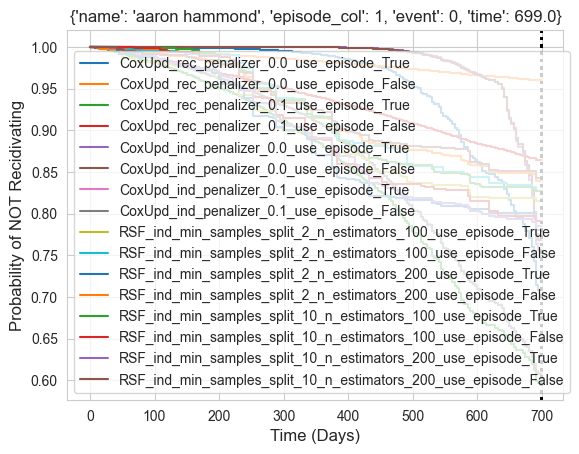

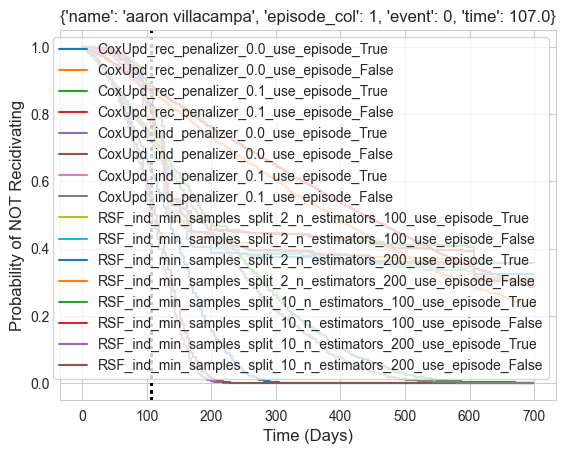

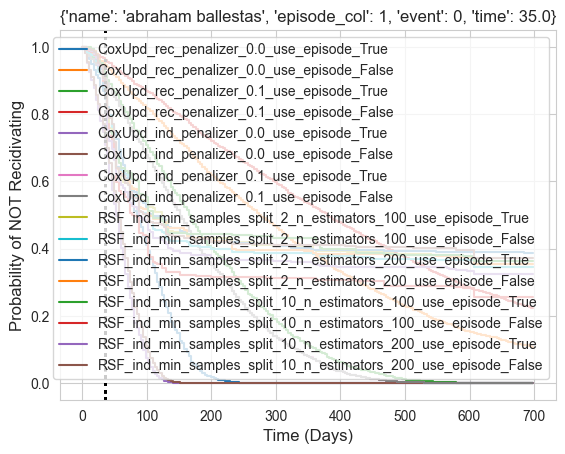

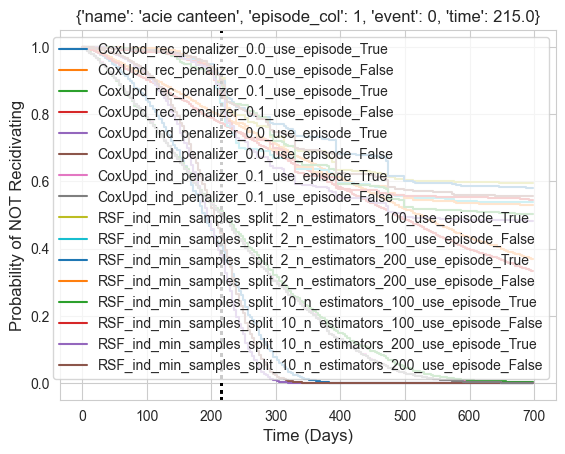

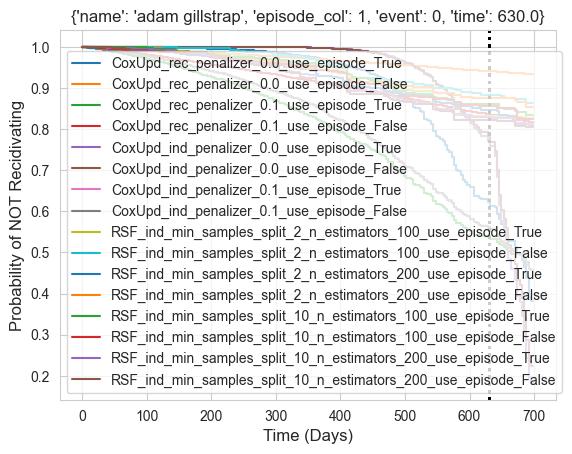

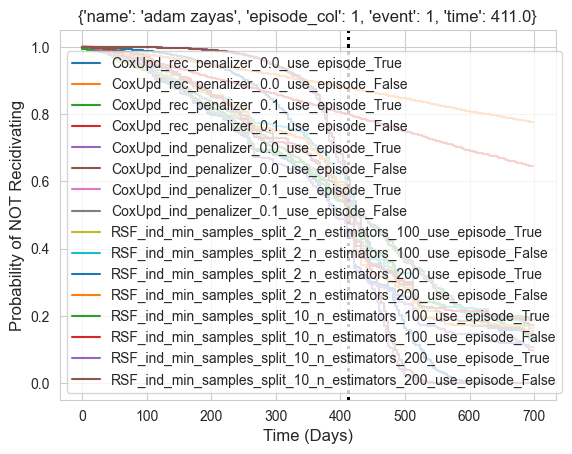

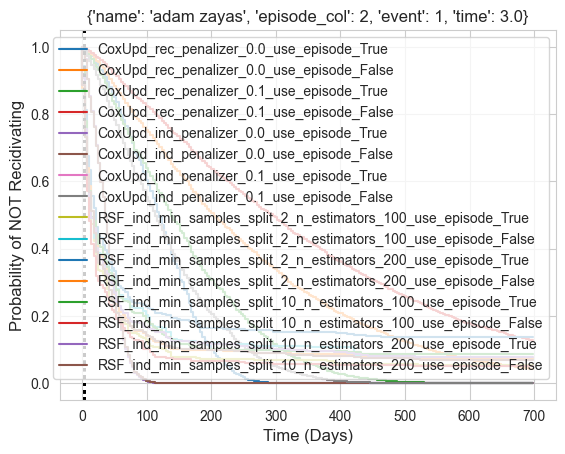

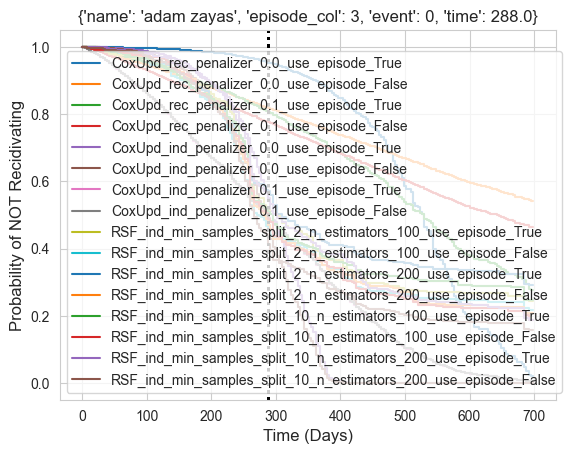

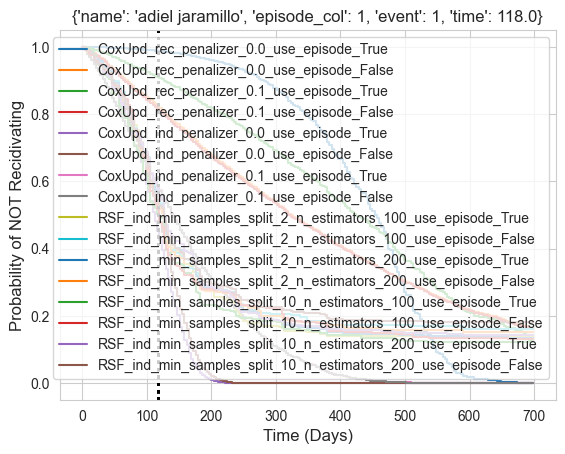

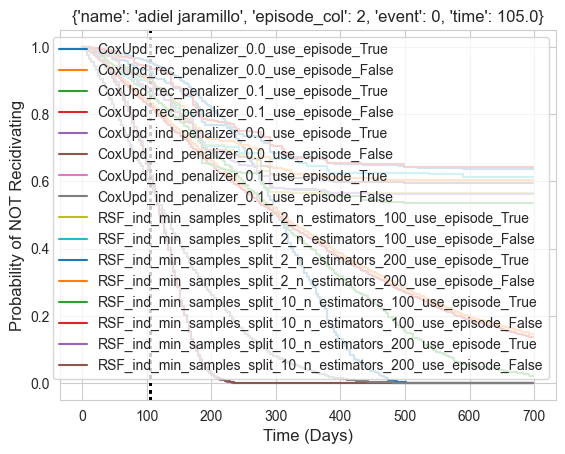

In [17]:
sns.set_style("whitegrid")

for index_test in range(10):
    for name, model in models.items():
        pred = model.predict_survival(test_model_df[features], times)
        plt.step(times, pred.iloc[index_test].values, label=name)
        sample_info = test_model_df.iloc[index_test]
        event_status = "Recidivated" if sample_info["event"] == 1 else "No Recidivism"
        time_to_event = sample_info["time"]
        plt.axvline(
            x=time_to_event,
            color="black",
            linestyle=":",
            linewidth=2,
        )
    # pred = rsf_model.predict_survival(test_model_df[rsf_model.features], times)
    # plt.step(times, pred.iloc[index_test].values, label="RSF_no_episode_col", color="red", linewidth=2)
    # sample_info = test_model_df.iloc[index_test]
    plt.xlabel("Time (Days)", fontsize=12)
    plt.ylabel("Probability of NOT Recidivating", fontsize=12)
    plt.legend()
    plt.title(f"{test_model_df.iloc[index_test][['name', 'episode_col', 'event', 'time']].to_dict()}")
    plt.show()